# Fiber Segmentation Tutorial with SAM2

The Segement-Anything-Model is current cutting edge instance segementation model from Facebook Research. It is based on so called Vision Transformers (ViT)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/colab_analysis.ipynb)

## Environment Set-up
If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [1]:
using_colab = True

### Load Packages

In [6]:
if using_colab:
    import os
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    # Install your repo from the dev branch
    !{sys.executable} -m pip install 'git+https://github.com/choROPeNt/segment-anything-2.git@dev'
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops, label
    import pandas as pd

    !mkdir -p ./images/
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/test.tiff
    !mkdir -p ./checkpoints/
    !wget -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
else:
    import os
    # if using Apple MPS, fall back to CPU for unsupported ops
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # quite nice life hack
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import matplotlib.pyplot as plt
    from PIL import Image
    import numpy as np
    from skimage.measure import regionprops, label
    import pandas as pd

PyTorch version: 2.8.0+cu126
Torchvision version: 0.23.0+cu126
CUDA is available: True
  Cloning https://github.com/choROPeNt/segment-anything-2.git (to revision dev) to /tmp/pip-req-build-tfmvpfvb
  Running command git clone --filter=blob:none --quiet https://github.com/choROPeNt/segment-anything-2.git /tmp/pip-req-build-tfmvpfvb
  Running command git checkout -b dev --track origin/dev
  Switched to a new branch 'dev'
  Branch 'dev' set up to track remote branch 'dev' from 'origin'.
  Resolved https://github.com/choROPeNt/segment-anything-2.git to commit 2819ea5de62570f54a7551359287ab68f4bd08ee
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--2025-10-23 12:23:21--  https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/test.tiff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercon

## Device Selection

PyTorch currently supports the following hardware acceleration backends and are recommended:

- **CUDA** — NVIDIA GPU acceleration (Linux and Windows)
- **MPS** — Metal Performance Shaders for Apple Silicon (macOS)
- **ROCm** — AMD GPU acceleration (Linux)

Other backends such as **XPU** (Intel) or **TPU** (Google Cloud) require separate extensions and are not part of the core PyTorch package.

| Backend    | Platform    |  PyTorch support   |  Notes   |
| --- | --- | --- | --- |
| `CUDA `   |  Linux / Windows   |  ✅ Fully supported   |  Standard GPU backend for NVIDIA cards.   |   
| `MPS`    |   macOS (Apple Silicon or AMD GPUs)  |  ✅ Supported (since 1.12)   |  Uses Apple Metal; some ops may still fall back to CPU. Some numerical differences to `CUDA`  |     
|  `ROCm`   |   Linux (AMD GPUs)  |  ✅ Supported (since 1.10, stable ≥ 1.12)   |  Official ROCm builds available from PyTorch.org.   |     
|   `XPU / SYCL`  |  Intel GPUs   |  🧪 Experimental   |  Via Intel Extension for PyTorch (not in core).   |    
|  `TPU`   |  Cloud (Google Colab `TPU` VMs)   |  ❌ Not in core PyTorch   |   Requires torch_xla separately.  |    





























In [8]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "\ngive numerically different outputs and sometimes degraded performance on MPS. "
        "\nSee e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


# Part 1: Single Image Analysis

## Load Image

**Note**: If your image is grayscale, you have to convert it to rgb to match SAM2 input size of `[x,y,3]`. The maximum image sizes is `1024**2`

In [12]:
file_path = "./images/test.tiff"

image = Image.open(file_path)

if image.mode in ("L", "I"):  # grayscale
    image = image.convert("RGB")
elif image.mode == "RGBA":    # drop alpha
    image = image.convert("RGB")

image_np = np.array(image)
print(f"Image has the shape {image_np.shape} and datatype {image_np.dtype}")

Image has the shape (728, 1630, 3) and datatype uint8


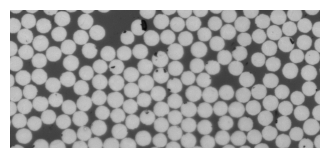

In [14]:
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

**Optional**: Center crop the image to match the input size

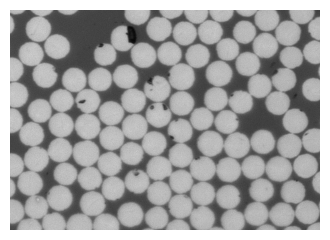

In [16]:
## center crop the image
def center_crop_np(image: np.ndarray, crop_size=1024):
    """Fast center crop for a NumPy image.

    Args:
        image (np.ndarray): Input image as a NumPy array (H, W) or (H, W, C).
        crop_size (int): Target crop size (assumes square crop).

    Returns:
        np.ndarray: Center-cropped image.
    """
    h, w = image.shape[:2]  # Get height and width
    ch, cw = crop_size, crop_size  # Crop size

    # Compute center crop coordinates
    start_h = max((h - ch) // 2, 0)
    start_w = max((w - cw) // 2, 0)
    end_h = min(start_h + ch, h)
    end_w = min(start_w + cw, w)

    return image[start_h:end_h, start_w:end_w]


image_np = center_crop_np(image_np)
## Show the Image
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

## Automatic mask generation
To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [23]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

sam2_checkpoint = "./checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
        model=sam2,
        points_per_side=48,
        # points_per_batch=96,
        pred_iou_thresh=0.1,
        # min_mask_region_area=500,
        box_nms_thresh=0.1,
        stability_score_thresh=0.95,  # Reduce the stability threshold to keep more masks
            )

To generate masks, simply call the generate function on an input image.

The resulting variable, masks, is a sequence of dictionaries, where each dictionary represents one detected region (fiber cross-section) and contains the following entries:
- segmentation : binary mask of the segmented region
- `area` : pixel area of the mask
- `bbox` : bounding box coordinates in the format `[x, y, width, height]`
- `predicted_iou` : model’s confidence estimate of segmentation accuracy (Intersection-over-Union (Jaccard) score)
- `point_coords` : coordinates of the prompt points used (if any)
- `stability_score` : measure of segmentation consistency under perturbations
- `crop_box` : image region from which the mask was generated

This output provides both the segmentation itself and useful metadata for filtering, analysis, or visualization.

In [19]:
print(f"Detection started...")
masks = mask_generator.generate(image_np)
print(f"Detection finished...")
print(f"Detected objects: {len(masks)}")

Detection started...
Detection finished...
Detected objects: 117


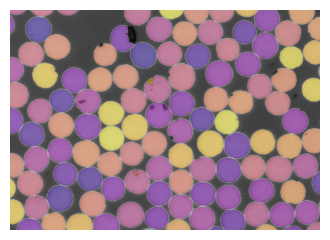

In [24]:
# Display some results
plt.figure(figsize=(4, 4))
plt.imshow(image_np)
label_map = show_anns(masks)
plt.axis('off')
plt.show()

## Statistics

Using the `label_map`, we can now extract quantitative information about the segmented fiber cross sections.
For this purpose, we apply the function `regionprops` (`regionprops_table` returns a pandas dataframe) from the `scikit-image` package, which computes a wide range of morphological and intensity-based statistics for each labeled region (comparable to 1D-descriptors).

Typical properties include:
- Area: number of pixels belonging to each fiber
- Centroid: spatial position of the fiber center
- Equivalent diameter: diameter of a circle with the same area as the fiber
- Eccentricity: measure of how elongated the fiber cross section is
- Orientation: local rotation of the fitted ellipse

These descriptors enable detailed quantitative analysis of fiber size, shape, and spatial distribution within the micrograph.